Reatlegile Sibanda ST10229185 - PDAN8411 POE PART1

Linear Regession Model

What is linear regression?

A fundamental supervised learning technique for establishing the relationship between a dependent variable and one or more independent variables is referred to as linear regression. This method predicts continuous values by fitting a straight line that best represents the data.  

It operates under the premise that there exists a linear relationship between the input and output, utilizing a best-fit line that is commonly used in predictive modeling, trend analysis, and forecasting (GeeksforGeeks, 2026).

Importing python libraries

In [1]:
!pip install seaborn 

Introduction

This analysis aims to construct a Linear Regression model intended for estimating medical insurance charges based on various customer characteristics. The dataset encompasses details regarding age, gender, BMI, number of dependents, smoking habits, geographical location, and medical insurance costs.  

The goal is to explore whether these demographic, lifestyle, and geographic factors can effectively predict individual medical charges. In this context, the charges will be designated as the target variable, while the other variables will initially serve as potential predictors.  

The analysis will encompass exploratory data analysis, data cleansing, feature selection, model training, evaluation, and enhancement. The findings will be interpreted from both statistical and business viewpoints.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

pd.set_option("display.max_columns", None)

print("All libraries imported successfully.")

All libraries imported successfully.


I have imported the metrics needed to gather my R squared and other performance metrics

Importing the dataset that comes from Kaggle formulated by Brett Lantz “Machine learning with R”

In [3]:
df = pd.read_csv("insurance.csv")

print("Dataset loaded successfully.")

Dataset loaded successfully.


Dataset Understanding

Before initiating the regression model construction, the dataset should be thoroughly reviewed to understand its structure, variables, and data types. This analysis is vital for determining the dataset's compatibility with Linear Regression and for recognizing any data-quality challenges that may need to be resolved.

In [4]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [5]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 1338
Number of columns: 7


In [6]:
print(df.columns.tolist())

['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 94.5 KB


The dataset was scrutinized for absent values, repeated records, erroneous entries, and atypical observations. The verification of data quality is essential, as flaws in the input data can detrimentally influence the regression model and its predictive outcomes.

In [8]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(1)

In [10]:
df = df.drop_duplicates()

print("Dataset shape upon the removal of duplicates:", df.shape)

Dataset shape upon the removal of duplicates: (1337, 7)


Descriptive statistics were computed to gain insights into the central tendency, dispersion, and range of the numerical variables. The mean signifies the average value, whereas the standard deviation reflects the degree of variation surrounding the mean.

In [11]:
df.describe()

,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121487
std,14.044333,6.100468,1.205571,12110.359656
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010


Exploratory Data Analysis 

An EDA was performed to uncover patterns, distributions, and correlations among the predictor variables and medical charges. Visual representations were employed as they facilitate the identification of trends, distinctions among groups, and possible outliers.

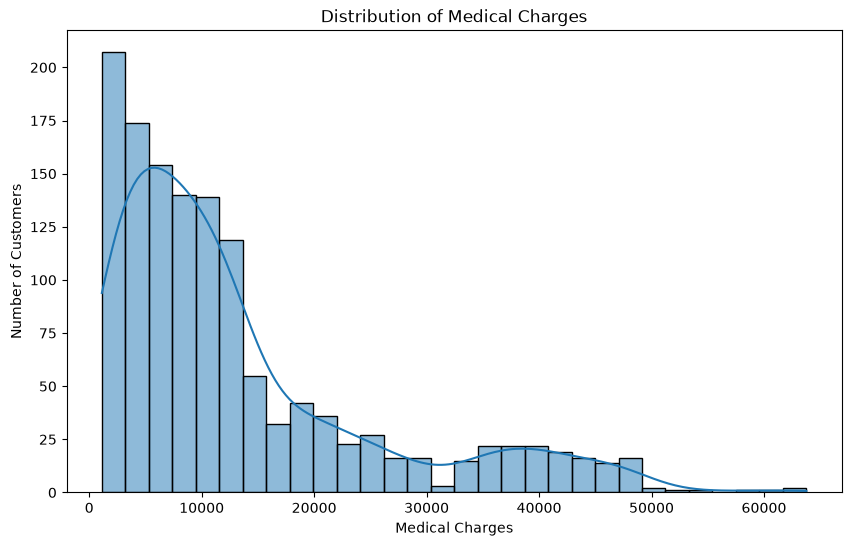

In [12]:
plt.figure(figsize=(10, 6))

sns.histplot(data=df, x="charges", bins=30, kde=True)

plt.title("Distribution of Medical Charges")
plt.xlabel("Medical Charges")
plt.ylabel("Number of Customers")

plt.show()

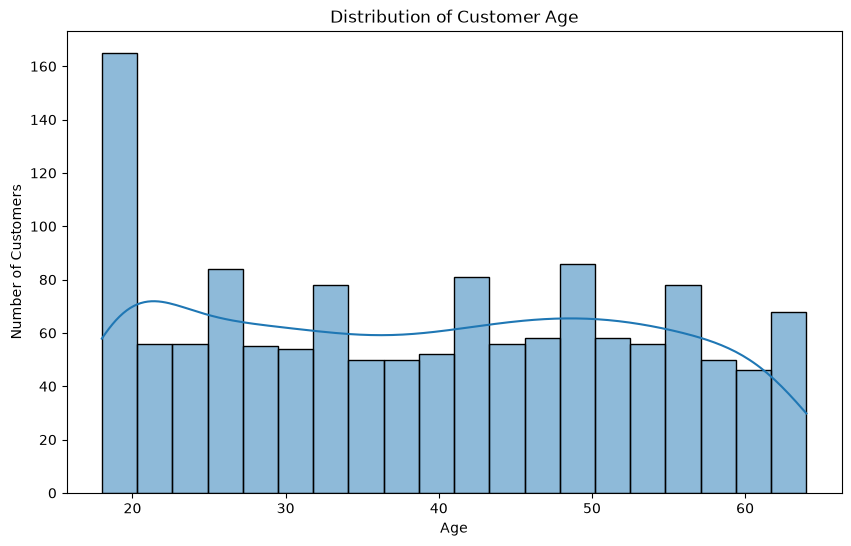

In [13]:
plt.figure(figsize=(10, 6))

sns.histplot(data=df, x="age", bins=20, kde=True)

plt.title("Distribution of Customer Age")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.show()

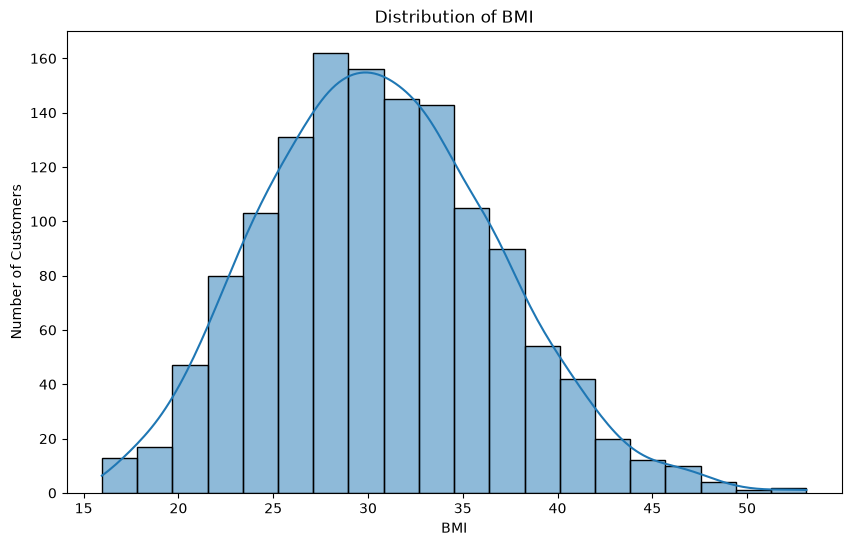

In [14]:
plt.figure(figsize=(10, 6))

sns.histplot(data=df, x="bmi", bins=20, kde=True)

plt.title("Distribution of BMI")
plt.xlabel("BMI")
plt.ylabel("Number of Customers")

plt.show()

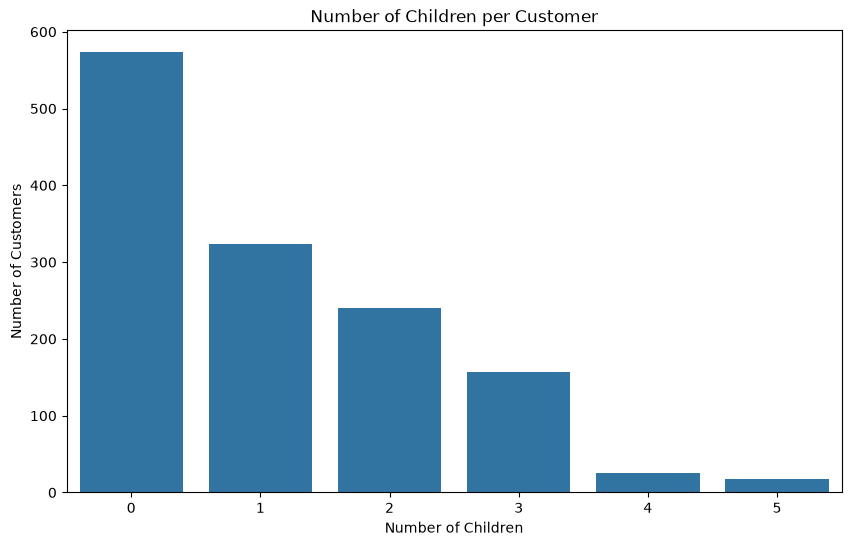

In [15]:
plt.figure(figsize=(10, 6))

sns.countplot(data=df, x="children")

plt.title("Number of Children per Customer")
plt.xlabel("Number of Children")
plt.ylabel("Number of Customers")

plt.show()

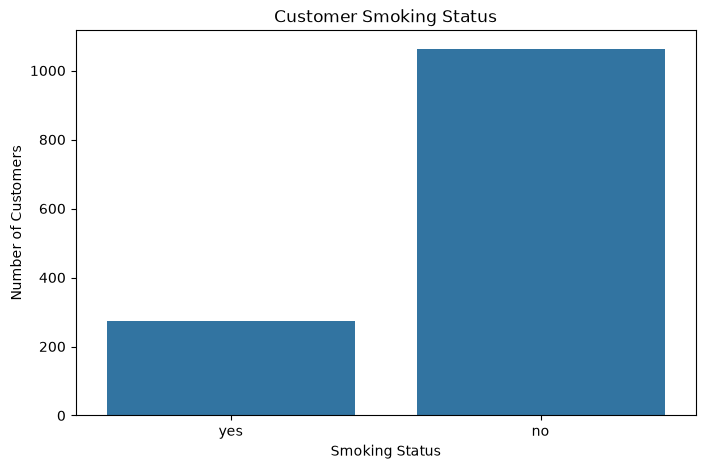

In [16]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="smoker")

plt.title("Customer Smoking Status")
plt.xlabel("Smoking Status")
plt.ylabel("Number of Customers")

plt.show()

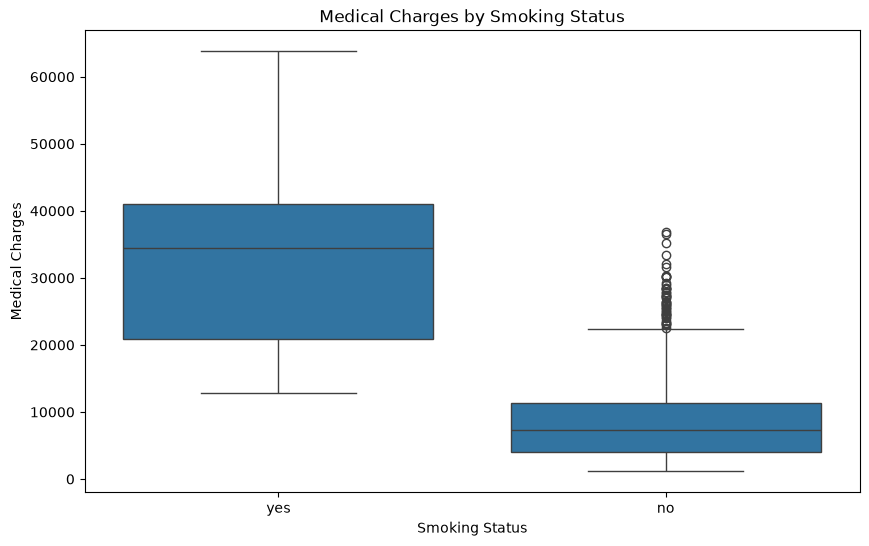

In [17]:
plt.figure(figsize=(10, 6))

sns.boxplot(data=df, x="smoker", y="charges")

plt.title("Medical Charges by Smoking Status")
plt.xlabel("Smoking Status")
plt.ylabel("Medical Charges")

plt.show()

Findinsgs upon plots 

A noticeable variation in medical fees can be observed between individuals who smoke and those who do not.  
In general, smokers tend to face considerably higher medical expenses. This implies that smoking status is likely to be a significant predictor of medical charges.

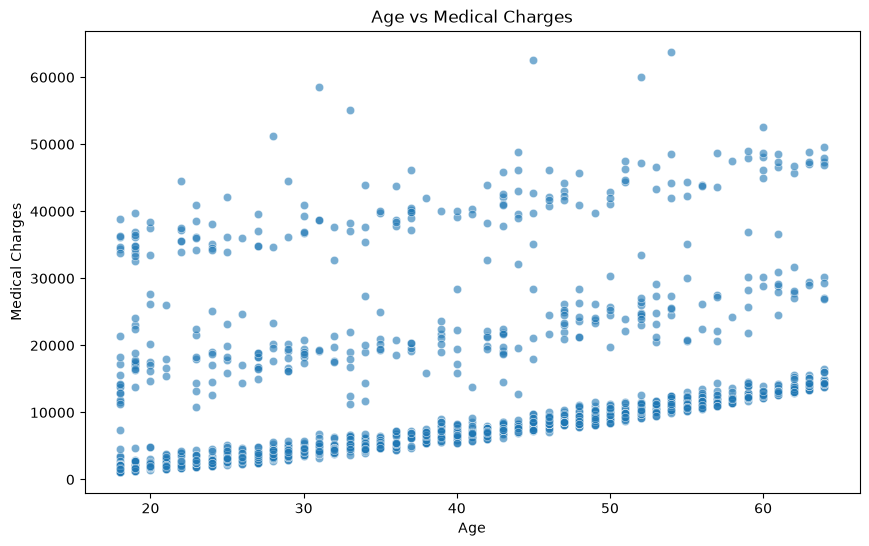

In [18]:
plt.figure(figsize=(10, 6))

sns.scatterplot(data=df, x="age", y="charges", alpha=0.6)

plt.title("Age vs Medical Charges")
plt.xlabel("Age")
plt.ylabel("Medical Charges")

plt.show()

Findings upon plot

There is a direct association between age and healthcare costs. With advancing age, medical charges typically escalate, albeit the correlation is not strictly linear. Moreover, certain subsets of observations display considerably elevated charges.

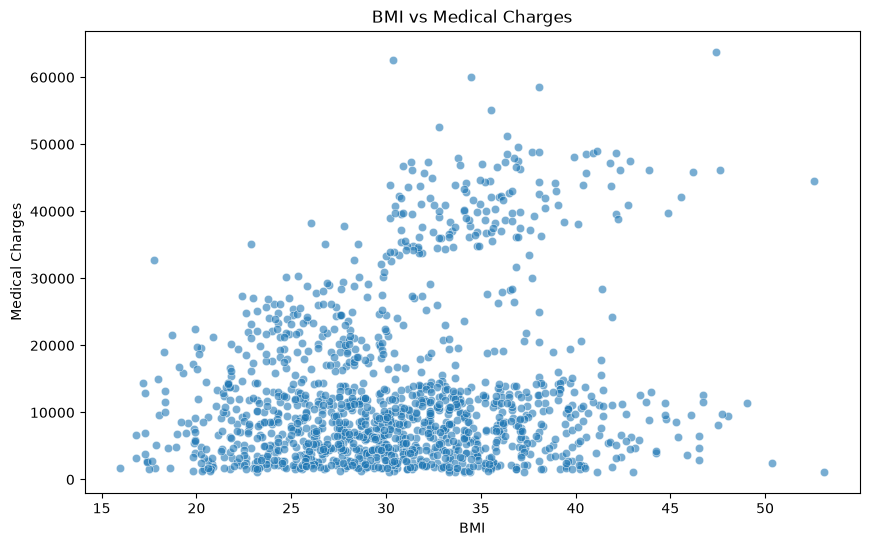

In [19]:
plt.figure(figsize=(10, 6))

sns.scatterplot(data=df, x="bmi", y="charges", alpha=0.6)

plt.title("BMI vs Medical Charges")
plt.xlabel("BMI")
plt.ylabel("Medical Charges")

plt.show()

Findgins upon plot

BMI is positively related to medical charges, although this relationship is not as strong as the one found between smoking status and medical expenses.

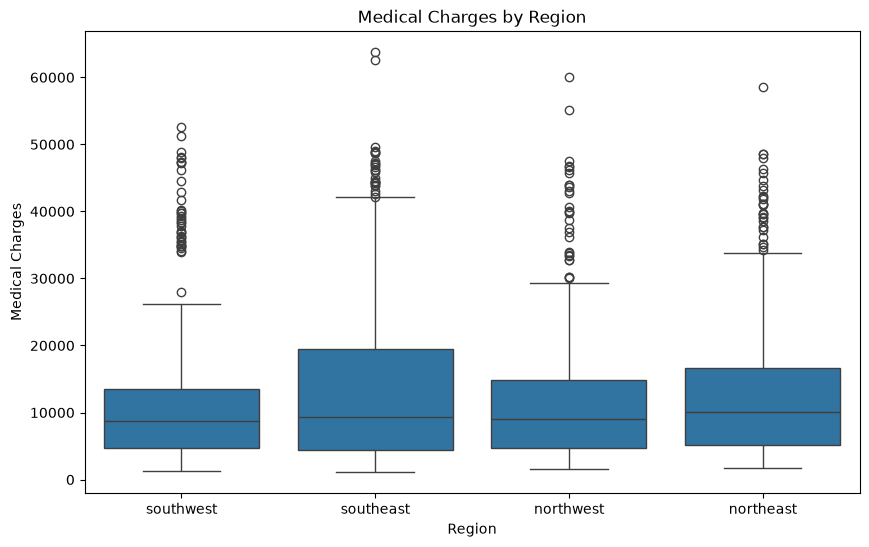

In [20]:
plt.figure(figsize=(10, 6))

sns.boxplot(data=df, x="region", y="charges")

plt.title("Medical Charges by Region")
plt.xlabel("Region")
plt.ylabel("Medical Charges")

plt.show()

Findings upon plot 

The expenses related to healthcare fluctuate depending on the region. However, the disparities are less visually striking compared to those associated with smoking habits.

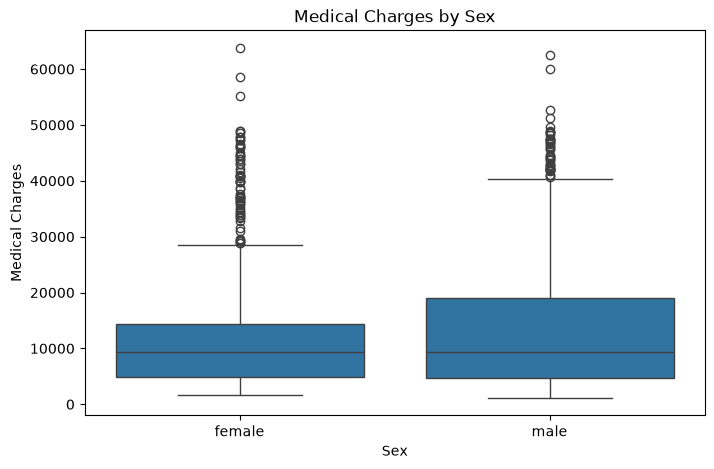

In [21]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="sex", y="charges")

plt.title("Medical Charges by Sex")
plt.xlabel("Sex")
plt.ylabel("Medical Charges")

plt.show()

Findings upon plot

There is some variation in medical charges between males and females, although the difference appears relatively small compared with the smoking-status difference.

Correlation Analysis

A correlation analysis was conducted to examine the strength and direction of linear relationships among numerical variables.
Correlation coefficients vary from -1 to +1. Coefficients approaching +1 suggest a robust positive linear relationship, whereas those nearing -1 indicate a strong negative relationship. Values that are close to zero reflect a weak linear relationship.



In [22]:
numerical_variables = ["age", "bmi", "children", "charges"]

correlation_matrix = df[numerical_variables].corr()

correlation_matrix

,age,bmi,children,charges
age,1.000000,0.109344,0.041536,0.298308
bmi,0.109344,1.000000,0.012755,0.198401
children,0.041536,0.012755,1.000000,0.067389
charges,0.298308,0.198401,0.067389,1.000000


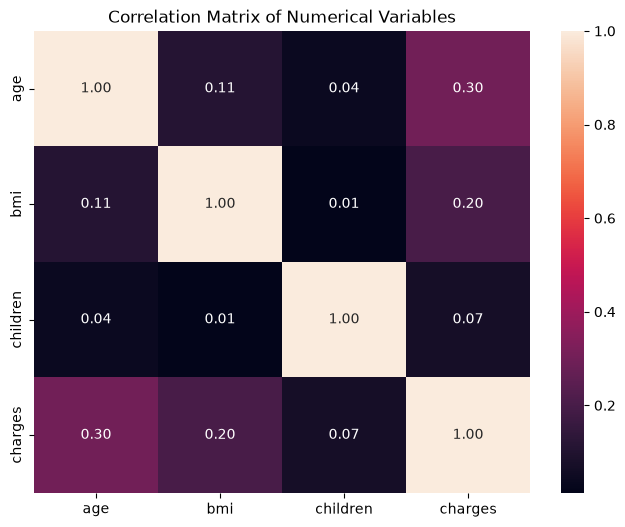

In [23]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Matrix of Numerical Variables")

plt.show()

Data Cleaning

The examination of data quality identified a single duplicate record. The missing-value analysis demonstrated that the dataset was devoid of any missing values. The numerical variables were also assessed for any impossible negative values or other invalid entries.

The duplicate record was discarded prior to the modeling stage. No further rows were eliminated, as the remaining observations included plausible values for age, BMI, number of children, and medical charges.



In [24]:
df_model = pd.get_dummies(
    df,
    columns=["sex", "smoker", "region"],
    drop_first=True,
    dtype=int
)

df_model.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,0,1,0,0,1
1,18,33.770,1,1725.55230,1,0,0,1,0
2,28,33.000,3,4449.46200,1,0,0,1,0
3,33,22.705,0,21984.47061,1,0,1,0,0
4,32,28.880,0,3866.85520,1,0,1,0,0


In [25]:
X = df_model.drop("charges", axis=1)

y = df_model["charges"]

print("Predictor variables:")
print(X.columns.tolist())

print("\nTarget variable:")
print("charges")

Predictor variables:
['age', 'bmi', 'children', 'sex_male', 'smoker_yes', 'region_northwest', 'region_southeast', 'region_southwest']

Target variable:
charges


The focus variable is charges, given that the intention is to predict the costs associated with medical insurance.  The predictor variables are age, BMI, the number of children, sex, smoking status, and region.  The predictors are stored in X, and the target variable is stored in y.

In [26]:
X = df_model.drop("charges", axis=1)

y = df_model["charges"]

print("Predictor variables:")
print(X.columns.tolist())

print("\nTarget variable:")
print("charges")

Predictor variables:
['age', 'bmi', 'children', 'sex_male', 'smoker_yes', 'region_northwest', 'region_southeast', 'region_southwest']

Target variable:
charges


In [27]:
X_with_constant = sm.add_constant(X)

ols_model = sm.OLS(y, X_with_constant).fit()

print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.751
Model:                            OLS   Adj. R-squared:                  0.749
Method:                 Least Squares   F-statistic:                     500.0
Date:                Mon, 14 Sep 2026   Prob (F-statistic):               0.00
Time:                        21:26:50   Log-Likelihood:                -13538.
No. Observations:                1337   AIC:                         2.709e+04
Df Residuals:                    1328   BIC:                         2.714e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const            -1.194e+04    988.227  

In [28]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [29]:
vif_data = pd.DataFrame()

vif_data["Feature"] = X_with_constant.columns

vif_data["VIF"] = [
    variance_inflation_factor(X_with_constant.values, i)
    for i in range(X_with_constant.shape[1])
]

vif_data

,Feature,VIF
0,const,35.504594
1,age,1.016794
2,bmi,1.106742
3,children,1.004017
4,sex_male,1.008944
5,smoker_yes,1.012100
6,region_northwest,1.517673
7,region_southeast,1.651779
8,region_southwest,1.529044


Train-Test Split

The dataset is segmented into two separate subsets. The training data is employed to educate the Linear Regression model, while the testing data is applied to gauge the effectiveness of the trained model on data that was not included in the training phase. 

An 80/20 ratio is adopted, with 80% of the observations designated for training and 20% set aside for testing. A random_state is established to allow for the reproducibility of the same split.

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training observations:", X_train.shape[0])
print("Testing observations:", X_test.shape[0])

Training observations: 1069
Testing observations: 268


Linear Regression Model

The application of Multiple Linear Regression is warranted as the target variable, medical charges, is continuous and there exist multiple predictor variables. 



In [31]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [32]:
y_pred = model.predict(X_test)

print("First five predictions:")
print(y_pred[:5])

First five predictions:
[ 8143.69388412  5737.11568259 14369.31487618 31745.51363586
  8962.38665706]


In [33]:
comparison = pd.DataFrame({
    "Actual Charges": y_test.values,
    "Predicted Charges": y_pred
})

comparison.head(10)

,Actual Charges,Predicted Charges
0,8688.85885,8143.693884
1,5708.86700,5737.115683
2,11436.73815,14369.314876
3,38746.35510,31745.513636
4,4463.20510,8962.386657
5,9304.70190,13149.722353
6,38511.62830,30446.760679
7,2150.46900,1453.288813
8,7345.72660,10633.018402
9,10264.44210,11318.943794


In [34]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients

,Feature,Coefficient
0,age,248.210720
1,bmi,318.701441
2,children,533.009989
3,sex_male,-101.542054
4,smoker_yes,23077.764593
5,region_northwest,-391.761455
6,region_southeast,-838.919616
7,region_southwest,-659.139752


In [35]:
print("Intercept:", model.intercept_)

Intercept: -11092.652295945943


Model Evaluation

The assessment of the model employs several metrics, including Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R-squared (R²). MAE indicates the average absolute difference between the actual charges and the predicted values, which is relatively easy to understand. 

MSE calculates the square of the prediction errors, thus placing more emphasis on larger errors.RMSE is the square root of MSE, which allows for the expression of prediction error in the same units as the target variable. R² evaluates the proportion of variance in medical charges that can be explained by the predictors present in the model.


In [36]:
mae = mean_absolute_error(y_test, y_pred)

print("MAE:", mae)

MAE: 4177.045561036319


In [37]:
mse = mean_squared_error(y_test, y_pred)

print("MSE:", mse)

MSE: 35478020.67523561


In [38]:
rmse = np.sqrt(mse)

print("RMSE:", rmse)

RMSE: 5956.342894363588


In [39]:
r2 = r2_score(y_test, y_pred)

print("R-squared:", r2)

R-squared: 0.8069287081198011


In [40]:
n = X_test.shape[0]
p = X_test.shape[1]

adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))

print("Adjusted R-squared:", adjusted_r2)

Adjusted R-squared: 0.8009651160926134


In [41]:
residuals = y_test - y_pred

print(residuals.head())

900      545.164966
1064     -28.248683
1256   -2932.576726
298     7000.841464
237    -4499.181557
Name: charges, dtype: float64


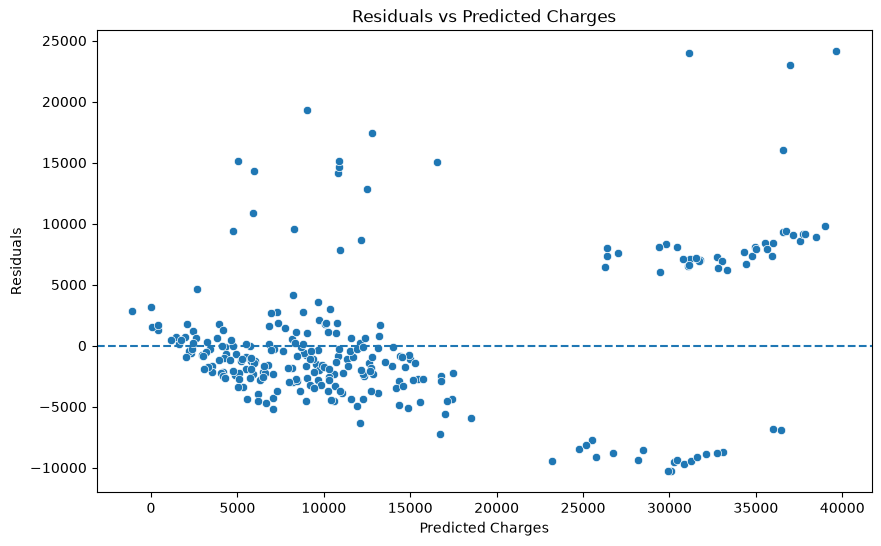

In [42]:
plt.figure(figsize=(10, 6))

sns.scatterplot(x=y_pred, y=residuals)

plt.axhline(0, linestyle="--")

plt.title("Residuals vs Predicted Charges")
plt.xlabel("Predicted Charges")
plt.ylabel("Residuals")

plt.show()

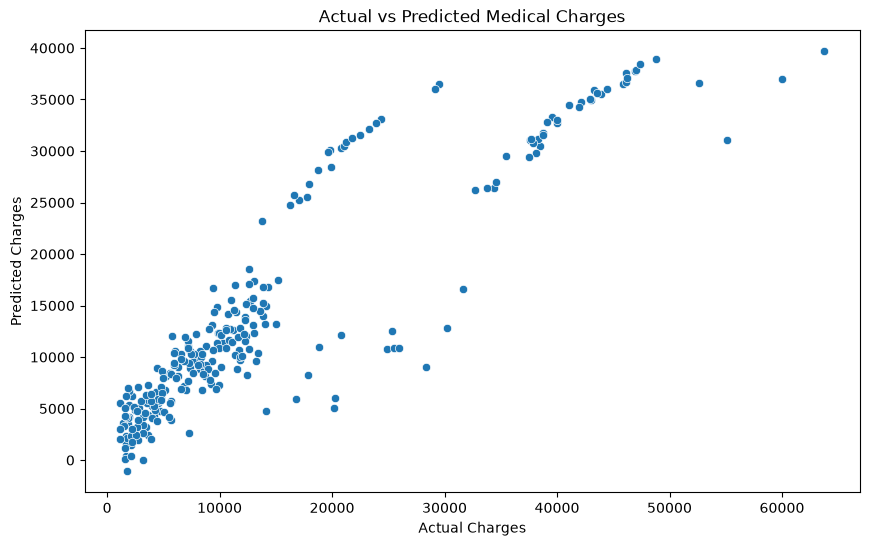

In [43]:
plt.figure(figsize=(10, 6))

sns.scatterplot(x=y_test, y=y_pred)

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")

plt.title("Actual vs Predicted Medical Charges")

plt.show()

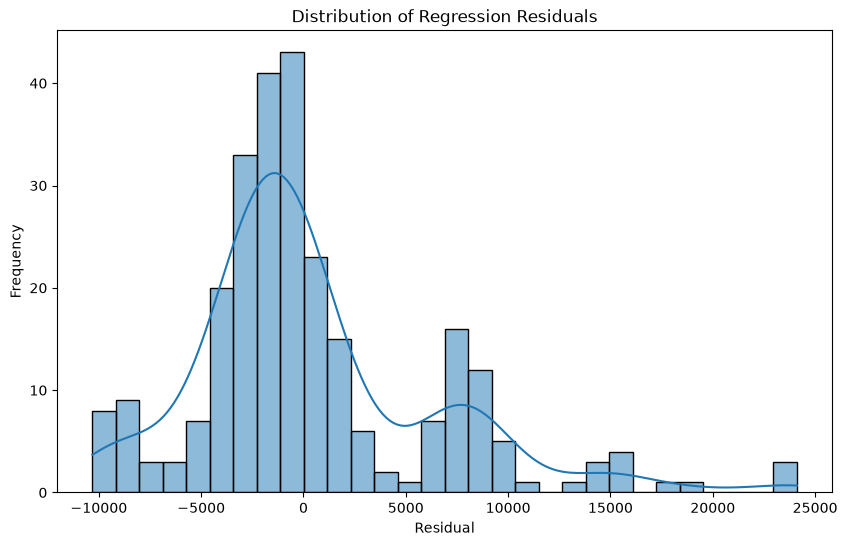

In [44]:
plt.figure(figsize=(10, 6))

sns.histplot(residuals, bins=30, kde=True)

plt.title("Distribution of Regression Residuals")
plt.xlabel("Residual")
plt.ylabel("Frequency")

plt.show()

In [45]:
df_improved = df_model.copy()

df_improved["bmi_smoker_interaction"] = (
    df_improved["bmi"] * df_improved["smoker_yes"]
)

df_improved.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest,bmi_smoker_interaction
0,19,27.900,0,16884.92400,0,1,0,0,1,27.9
1,18,33.770,1,1725.55230,1,0,0,1,0,0.0
2,28,33.000,3,4449.46200,1,0,0,1,0,0.0
3,33,22.705,0,21984.47061,1,0,1,0,0,0.0
4,32,28.880,0,3866.85520,1,0,1,0,0,0.0


Upon adjustments, training the improved model

In [46]:
X_improved = df_improved.drop("charges", axis=1)

y_improved = df_improved["charges"]

X_train_imp, X_test_imp, y_train_imp, y_test_imp = train_test_split(
    X_improved,
    y_improved,
    test_size=0.20,
    random_state=42
)

improved_model = LinearRegression()

improved_model.fit(X_train_imp, y_train_imp)

y_pred_imp = improved_model.predict(X_test_imp)

print("Improved model trained successfully.")

Improved model trained successfully.


In [47]:
mae_imp = mean_absolute_error(y_test_imp, y_pred_imp)

mse_imp = mean_squared_error(y_test_imp, y_pred_imp)

rmse_imp = np.sqrt(mse_imp)

r2_imp = r2_score(y_test_imp, y_pred_imp)

n_imp = X_test_imp.shape[0]
p_imp = X_test_imp.shape[1]

adjusted_r2_imp = 1 - (
    (1 - r2_imp) * (n_imp - 1) / (n_imp - p_imp - 1)
)

print("Improved Model Results")
print("----------------------")
print("MAE:", mae_imp)
print("MSE:", mse_imp)
print("RMSE:", rmse_imp)
print("R-squared:", r2_imp)
print("Adjusted R-squared:", adjusted_r2_imp)

Improved Model Results
----------------------
MAE: 2828.9737471039484
MSE: 20910602.630768426
RMSE: 4572.8112393546735
R-squared: 0.8862045574393044
Adjusted R-squared: 0.8822349489778848


In [48]:
model_comparison = pd.DataFrame({
    "Metric": [
        "MAE",
        "MSE",
        "RMSE",
        "R-squared",
        "Adjusted R-squared"
    ],
    
    "Baseline Model": [
        mae,
        mse,
        rmse,
        r2,
        adjusted_r2
    ],
    
    "Improved Model": [
        mae_imp,
        mse_imp,
        rmse_imp,
        r2_imp,
        adjusted_r2_imp
    ]
})

model_comparison

,Metric,Baseline Model,Improved Model
0,MAE,4.177046e+03,2.828974e+03
1,MSE,3.547802e+07,2.091060e+07
2,RMSE,5.956343e+03,4.572811e+03
3,R-squared,8.069287e-01,8.862046e-01
4,Adjusted R-squared,8.009651e-01,8.822349e-01


Conclusion

Exploratory Data Analysis revealed several significant patterns. Medical charges exhibited a pronounced right skew, characterized by a small subset of customers incurring markedly higher charges. A positive correlation was observed between age and medical charges, whereas the relationship between BMI and charges was comparatively weaker. Notably, smoking status displayed one of the most distinct disparities in charges, with smokers typically facing significantly higher medical expenses than their non-smoking counterparts.

Correlation analysis indicated a positive correlation of approximately 0.299 between age and charges, while BMI demonstrated a correlation of around 0.198, and the number of children showed a weak correlation of about 0.068. These findings suggest that simple correlation metrics do not adequately encapsulate all relationships present in the dataset, especially concerning categorical variables.

The categorical predictor variables were transformed into numerical variables through one-hot encoding. Subsequently, a multiple Linear Regression model was developed utilizing an 80/20 training and testing split. The model's performance was assessed using metrics such as MAE, MSE, RMSE, R-squared, and adjusted R-squared.

The baseline model serves as a valuable foundation for forecasting medical charges. Nevertheless, the considerable variability in medical charges implies that the associations between the predictors and charges are not entirely straightforward or linear. Consequently, an enhanced model was evaluated by incorporating an interaction term between BMI and smoking status.

In general, Linear Regression serves as an appropriate initial modeling approach due to the continuous nature of the target variable, which is medical charges, and the presence of several potential predictors within the dataset. Furthermore, the analysis highlights the importance of assessing model performance instead of presuming a model's adequacy solely based on its ability to produce predictions.